In [1]:
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd

In [2]:
df = pd.read_csv('bbc_news_dataset.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB
None


In [3]:
X = df['Text']
y = df['Category']
print(X.shape, y.shape)

(1490,) (1490,)


In [4]:
category_names = df['Category'].unique()
print(category_names)

['business' 'tech' 'politics' 'sport' 'entertainment']


In [5]:
value_counts= df['Category'].value_counts()
print(value_counts)

Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


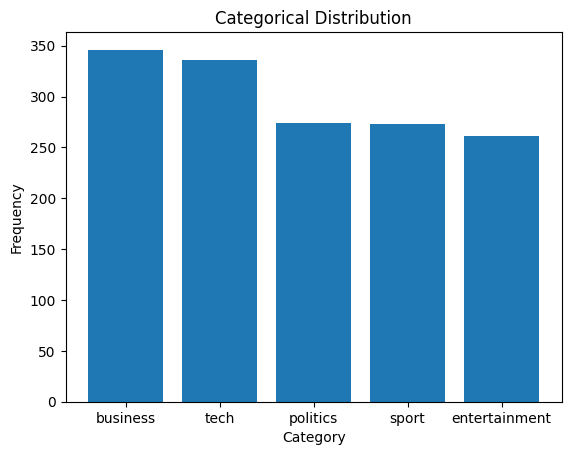

In [6]:
plt.bar(x=category_names, height=value_counts)
plt.title('Categorical Distribution')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

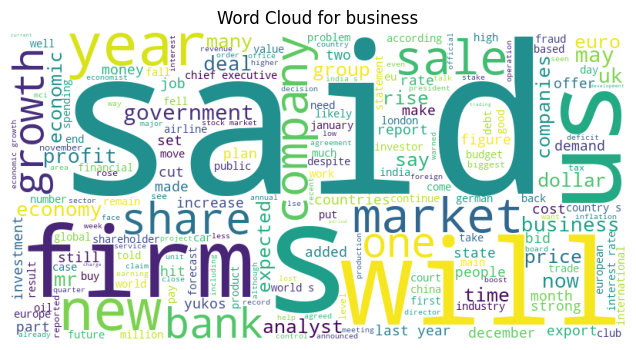

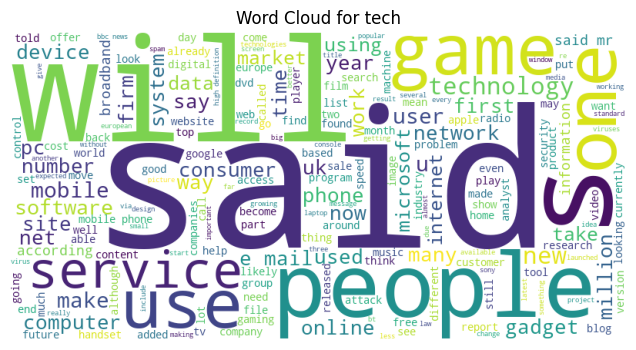

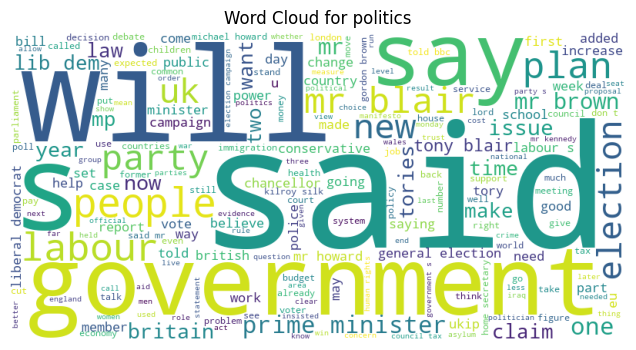

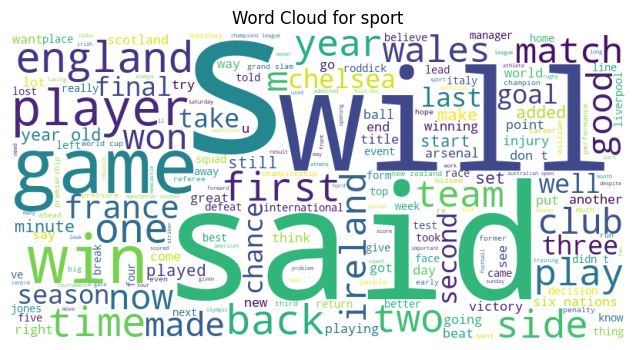

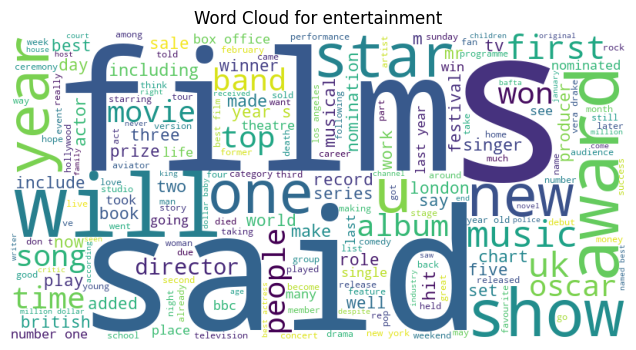

In [7]:
for category in category_names:
    text = " ".join(df[df['Category']==category]['Text'].values)
    wc = WordCloud(width=800,height=400, background_color='white').generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc) # Displays the generated Word Cloud image.
    plt.axis('off') # Removes the x-axis and y-axis.
    plt.title(f"Word Cloud for {category}")
    plt.show()

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
from sklearn.pipeline import make_pipeline 

#converts text into numerical features that a machine learning algorithm can understand.
from sklearn.feature_extraction.text import TfidfVectorizer

# learns from those features and their labels during fit().
from sklearn.naive_bayes import MultinomialNB
model = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB()
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



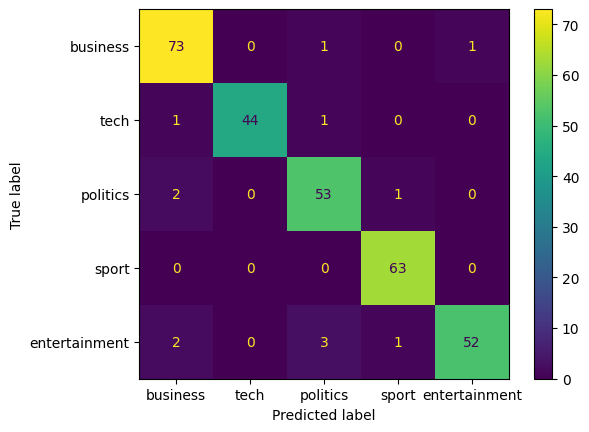

In [11]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=category_names).plot()

In [12]:
texts = [ "The government introduced a new education policy that was approved by parliament. Opposition leaders demanded further debate before its nationwide implementation."]

prediction = model.predict(texts)
print(prediction)

['politics']


In [13]:
import joblib
joblib.dump(model,'model.joblib')
print('SUCCESS')

SUCCESS


#### 1. Evaluate the model using Accuracy, Precision, Recall, and F1-Score. Analyze the results.


Accuracy: 0.9564  Precision: 0.9575  Recall: 0.9564  F1: 0.9563
               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



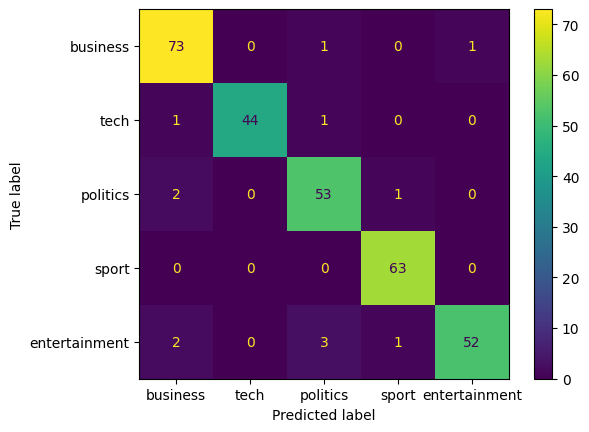

In [14]:

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=category_names).plot()


#### 2. Experiment with TF-IDF parameters such as max_features, ngram_range, and min_df.


In [15]:
configs = [
    {'max_features': None, 'ngram_range': (1, 1), 'min_df': 1},
    {'max_features': 3000, 'ngram_range': (1, 1), 'min_df': 1},
    {'max_features': 5000, 'ngram_range': (1, 2), 'min_df': 2},
    {'max_features': 10000, 'ngram_range': (1, 2), 'min_df': 3},
]
for cfg in configs:
    m = make_pipeline(TfidfVectorizer(stop_words='english', **cfg), MultinomialNB())
    m.fit(X_train, y_train)
    y_pred_cfg = m.predict(X_test)
    # print(classification_report(y_test, y_pred_cfg))

    acc = accuracy_score(y_test, y_pred_cfg)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_cfg, average='weighted')
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")


Accuracy: 0.9564  Precision: 0.9575  Recall: 0.9564  F1: 0.9563
Accuracy: 0.9698  Precision: 0.9700  Recall: 0.9698  F1: 0.9699
Accuracy: 0.9765  Precision: 0.9765  Recall: 0.9765  F1: 0.9765
Accuracy: 0.9698  Precision: 0.9700  Recall: 0.9698  F1: 0.9697


####  3. Classify at least five custom news articles and record the predicted categories.

In [16]:
custom_articles = [
    "The central bank raised interest rates to control inflation.",
    "The movie won three awards at the film festival this year.",
    "The government passed a new law after parliament debate.",
    "The team won the championship with a last-minute goal.",
    "The company launched a new smartphone with a faster processor.",
]
custom_preds = model.predict(custom_articles)
for text, pred in zip(custom_articles, custom_preds):
    print(f"{text} ------ {pred} articles")

The central bank raised interest rates to control inflation. ------ business articles
The movie won three awards at the film festival this year. ------ entertainment articles
The government passed a new law after parliament debate. ------ politics articles
The team won the championship with a last-minute goal. ------ sport articles
The company launched a new smartphone with a faster processor. ------ tech articles


####  4. Save the trained model and reload it to perform predictions on new data

In [17]:
import joblib

model = joblib.load('model.joblib')
texts = ["The government announced a new education policy."]
prediction = model.predict(texts)
print(prediction)

['politics']


##### 5 & 6. Experiment with Train-Test Split Ratio. Evaluate the model using different train-test splits: 70% – 30%, 80% – 20%, 90% – 10%. Compare the resulting accuracies.

In [18]:
train_test_ratio = [(0.3, '70-30'), (0.2, '80-20'), (0.1, '90-10')]
for test_size, label in train_test_ratio:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    model = make_pipeline(TfidfVectorizer(stop_words='english'), MultinomialNB())
    model.fit(X_train, y_train)
    a = accuracy_score(y_test, model.predict(X_test))
    print(f"{label} split ----> accuracy = {a:.4f}")

70-30 split ----> accuracy = 0.9687
80-20 split ----> accuracy = 0.9564
90-10 split ----> accuracy = 0.9597


##### 7 & 8. Perform 5-Fold Cross Validation and calculate Mean Accuracy and Standard Deviation. Discuss whether the model is stable across different folds.

In [19]:
from sklearn.model_selection import cross_val_score

cv_model = make_pipeline(TfidfVectorizer(stop_words='english'), MultinomialNB())
scores = cross_val_score(cv_model, X, y, cv=5)
print(f"Fold scores: {scores}")
print(f"Mean accuracy: {scores.mean():.4f}, Std dev: {scores.std():.4f}")
print("Stable across folds" if scores.std() < 0.02 else "Some variation across folds")

Fold scores: [0.96308725 0.95302013 0.96979866 0.97986577 0.96644295]
Mean accuracy: 0.9664, Std dev: 0.0088
Stable across folds


##### 9. Train and prepare a comparison table showing: Accuracy , Training Time , Prediction Time        - Multinomial Naïve Bayes - Logistic Regression - Support Vector Machine (SVM) 

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import time


In [23]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': LinearSVC(),
}
results = []
for name, clf in models.items():
    pipe = make_pipeline(TfidfVectorizer(stop_words='english'), clf)

    start = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    preds = pipe.predict(X_test)
    predict_time = time.time() - start

    a = accuracy_score(y_test, preds)
    results.append([name, a, train_time, predict_time])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Train Time (s)', 'Predict Time (s)'])
print(results_df)

                 Model  Accuracy  Train Time (s)  Predict Time (s)
0          Naive Bayes  0.959732        0.839568          0.106530
1  Logistic Regression  0.966443        1.338002          0.080366
2                  SVM  1.000000        0.901451          0.080880


##### 10.  Build a News Recommendation Prototype: After classifying an article, display three similar articles from the same category using cosine similarity.

In [91]:
from sklearn.metrics.pairwise import cosine_similarity

# stop_words='english' tells it to remove common English words
tfidf = TfidfVectorizer(stop_words='english') 
tfidf_matrix = tfidf.fit_transform(df['Text'])
# fit_transsform - learns the vocabulary and IDF scores from the given text, then converts it into TF-IDF vectors. 

def recommend(article_text, top_n=3):
    category = model.predict([article_text])[0]
    same_category_text = df[df['Category'] == category]
    query_vec = tfidf.transform([article_text])
    # tranform - reuses the already-learned vocabulary and IDF scores to convert new text into TF-IDF vectors in that same space.

    sims = cosine_similarity(query_vec, tfidf_matrix[same_category_text.index]).flatten()
    top_idx = sims.argsort()[::-1][:top_n] 
    # srgsort() It does not sort the values. It returns the indices that would sort the array.
    return category, same_category_text.iloc[top_idx]

category, similar = recommend(custom_articles[2])
print(f"Predicted category: {category}")
print(similar[['ArticleId', 'Text']])

Predicted category: politics
      ArticleId                                               Text
1423          7  blair prepares to name poll date tony blair is...
772         543  act on detention ruling  uk urged the governme...
1416       1355  tories attack burglar  u-turns  tory leader mi...
